[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kanchukaitis/paleoCAMP/blob/main/python_for_climate_part1.ipynb)


# Introduction to Python for Paleoclimate Science — Part 1: Python, NumPy, and Pandas

Welcome! This is the first of two short notebooks to help you get comfortable with Python for climate and paleoclimate research before paleoCAMP. It assumes you may have programmed a least a little bit before (perhaps in MATLAB or R) but are relatively new to Python.  If you have Python experience, this may be too basic, but it could still be a useful refresher. 

**This notebook covers:**
1. The basics of what Python is and how it differs from other languages
2. Python as a calculator — using variables and basic math
3. Data types
4. Installing and importing packages
5. NumPy — arrays and array operations
6. Pandas — DataFrames, time series, and CSV files

**Part 2** will cover Xarray (for netCDF files and multidimensional data), Matplotlib plotting, and Cartopy mapping.



## 1. What Is Python?

Python is an **interpreted** (not compiled), **object-oriented**, free (as in beer), and open-source language.  **Object-oriented** means that the data and the functions that operate on it are bundled together, with certain classes of data having particular methods and properties attached to them explicitly.  You'll see this most clearly as the `variable.method()` syntax throughout the Python ecosystem.  Note that methods and mathematical operations associated with an object typically have the `()` after which can be used to pass additional inputs, while getting the attributes and properties of an object (e.g. `.shape`) do not.  In most cases you can string together operations in a single line using repeated `.` between operations, for instance: `temperatures.mean().round(2)` would take an array of temperature data, calculate their overall mean value, and round the resulting output to 2 decimal places, all on a single line of code. 

Python has a few specific characteristics to be aware of, especially if you are coming from another programming language.  First and foremost, it is *zero-indexed*, meaning that counting things (like columns, rows, entries in a list, etc.) starts at *0*, instead of 1. Python also uses what is called 'half-open intervals' when specifiying a range of items or values, which can be confusing and will be explained more below. Comments in your code will start with `#` in Python.  And blocks of code like loops are structured using indentation instead of being visibly terminated by an `end` statement or offset with braces `{}`.  If you're interested in why Python evolved it way it did, some of these syntax oddities can be understood by reading [the philosophy and maths described in this older essay by Edsger W. Dijkstra](https://www.cs.utexas.edu/~EWD/transcriptions/EWD08xx/EWD831.html).  

One final note before we start: In Jupyter notebooks and in Colab, Python will not print the outcome of operations or assignments that are done in the middle of code blocks, so you have to use and explicit `print()` command to show the value after the code block (e.g. to print the value to the screen).


## 2. Python as a Calculator

At its most basic, Python can do artimatic operations just like a calculator.  You can see these listed [here](https://codingnomads.com/python-arithmetic-operators) and most of these will be familiar to you and are consistent from programming language to programming language (although see how Python does exponents!):

In [1]:
# Basic arithmetic - most of the operators will look familiar - 
print(3 + 4) # use print() so the outcome of the operation prints to the notebook after the code block
print(4 / 3)      
print(2 ** 8) # 2 to the power 8 — Python uses ** not the ^ for exponents

7
1.3333333333333333
256


Most of the time though we'll assign value to variables and use these for further calculations:

In [2]:
# Variables and assignment
a = 3
b = 4
print(a + b)
print(b ** a)   # b to the power of a

# Python allows you to make multiple assignment at once
x, y, z = 1, 2, 3
print(x, y, z)

7
64
1 2 3


Beware of when making copies of variables using `=`!  Let's say you create a variable `a`, and then make a copy of `a`, by writing `b = a` -- you might think these are independent (and, indeed in MATLAB for instance they are), but in many cases Python understands this as a pointer to the original data  (that is, `b` points to the contents of `a`) and not an independent variable.  This is efficient (in that it saves resources) but dangerous:

In [3]:
a = [1, 2, 3]
b = a           # b now points to the same list as a
a.append(4)     # we can change a
print(b)        # [1, 2, 3, 4] — but b "sees" the change too! 

[1, 2, 3, 4]


Yikes! The solution is to use the `.copy()` method to create a truly separate, independent copy that will no longer be linked to the original data:

In [4]:
a = [1, 2, 3]
b = a.copy()    # b points to the same list as a
a.append(4)     # we can change a
print(b)        # and here b is still the same as when we made it a copy of a

[1, 2, 3]


### Indentation is meaningful!

Unlike MATLAB (which uses `end`) or R (which typically uses `{}`), Python uses indentation to define code blocks. In CoLab and Jupyter, the tab creates 4 spaces:

In [5]:
x = 1
y = 2

if x < y: # loop starts here, note the use of the :
    print('x is smaller')   # 4 spaces to offset, everything at this indent is in the loop
    print('we are still inside the loop')   # same indent so the same block of code
print('we are now outside the loop ')  # no indent, so this is separate from the previous lines 


x is smaller
we are still inside the loop
we are now outside the loop 


## 3. Data Types

Python is a dynamic (a variable can hold any data type and the specific type is figured out when you run the code) but strongly typed language.  Python operations really care what type of data your variable is, and will do little to help you if the types of data and operations make them incompatible (in contrast, MATLAB does its best to figure out how to make it possible to do your operation for most data types, for better or for worse).  

Python's core data types are:

| Type | Example | Notes |
|---|---|---|
| `int` | `7` | Integer |
| `float` | `7.0`, `3.14` | Floating point |
| `str` | `'hello'` | Text |
| `bool` | `True`, `False` | Boolean |
| `list` | `[1, 2, 3]` | Ordered, mutable, zero-indexed |
| `tuple` | `(1, 2, 3)` | Ordered, **immutable** |
| `dict` | `{'key': value}` | Key-value pairs |

Use `type()` around any variable to check what you have.  This can be useful for troubleshooting. 

Data types can be set explicitly (declared), but are often determined by their literal syntax.  So for example, a number without a decimal point is given an `int` type, while including a decimal (even if it is just zero) results in a floating point data type:

You'll probably encounter all of the Python data types fairly early in your coding journey.  Integers and floating point numbers are of course what most of our data will be.  Booleans are the result of comparisons or indexing.  Dictionaries are good ways to hold structured data.  

In [ ]:
print(type(7))      # with no decimal, this will be a integer!
print(type(7.0))    # with a decimal, this will be a float!
print(type('yo!'))  # a string, obviously
print(type(True))   # Boolean

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


We'll often use strings for labeling things (axes, data points).  Python syntax treats either `''` or `""` the same.  Like integers or floating point numbers, strings are objects with specific methods, so we can convert strings to upper or lower case, for instance. We can also slice and dice them.  Finally, f-strings (formatted strings) allow us to mix strings and variables as well:

In [7]:
# In Python, both single or double quotes work for strings
name = 'paleoclimatology'
print(name.upper())         # strings have methods attached to them just like numerical data types
print(name[0:5])            # slice first 5 characters (zero-indexed) - note the half-open interval here - the letter in position 5 is not included in the slice! 
print(len(name))            # len() is a function that returns the length of the string 

# f-strings (formatted strings): the easiest way to embed or mix variables with text
year = 2026
print(f'The year is {year} and the word paleoclimatology has {len(name)} letters.')

PALEOCLIMATOLOGY
paleo
16
The year is 2026 and the word paleoclimatology has 16 letters.


Lists are a simple variable type that allows us to have multiple numbers or strings in a certain order.  These are declared with a equal sign, inside square brackets, and commas separating the individual values.  We can slice and dice lists, extract 1 or more variables, append to them, etc. etc.  Lists are relatively basic, however.  A bit later, we'll learn about more powerful `array` types. 

In [ ]:
# Lists: ordered, can be changed (mutable), and always zero-indexed
temp = [12.1, 14.3, 11.8, 15.0, 13.6] # inside square brackets, separated by commas
print(temp[0])     # first (0th) element — remember the index is 0, NOT 1!  Yes, I know, I know. 
print(temp[-1])    # use this to select the last element in a list (a negative index counts from the end of the list)
print(temp[1:4])   # 3 values returned, not 4 - the half-open interval again - the elements at indices 1, 2, 3 are included — the stop value of 4 is NOT included

# Lists are mutable, meaning you can change them in place
temp.append(14.8)   # append a value to the end of the existing list 
print(temp)

12.1
13.6
[14.3, 11.8, 15.0]
[12.1, 14.3, 11.8, 15.0, 13.6, 14.8]


Unlike lists, tuples are immutable (meaning you can't change them manually). They are most often encountered in situations where you don't want to be able to change them - for instance, if you get the shape of an array as a result of a command `.shape()`, you shouldn't be able to change the resulting size output yourself (because the shape is a property of the array you were just measuring). If you're declaring your own tuple, you use parentheses to indicate this (not square brackets, as in the list):

In [9]:
# Tuples: like lists but immutable — elements can't be changed - used for things that belong together: lat and lon, an array shape
location = (-110.97, 32.25)   # Tucson, AZ - tuples are declared with simple parentheses and comma-separated
print(location[0])            # access like a list
# location[0] = -111.0        # this would raise an error — tuples are immutable and we can't change one like this

-110.97


Dictionaries hold key-value pairs, which is a nice way to hold meta-data or to indicate that there is a structural relationship between or within categories and data.  Dictionaries are created using {}.  We can then access the value by referencing the key as a string in square brackets after the name of the dictionary (e.g. `dictionaryName["key"]`)

In [10]:
# Dictionaries use key-value pairs — useful for named metadata for instance
site = { # use {} to create dictionaries
    'sitename': 'Mount Lemmon',
    'lon': -110.79,
    'lat': 32.44,
    'elev_m': 2791
}
print(site['sitename']) # prints the value associated with the key "name"
print(site['elev_m']) # prints the value associated with the key "elev_m"

# Add a new key - dictionaries are mutable:
site['species'] = 'Pinus strobiformis'
print(site)

Mount Lemmon
2791
{'sitename': 'Mount Lemmon', 'lon': -110.79, 'lat': 32.44, 'elev_m': 2791, 'species': 'Pinus strobiformis'}


You'll most often encounter Booleans (`True` or `False`) when making comparisons between values and when indexing into a data structure.  They are also often used to pass commands to function (e.g `detrend=True`). Note that Booleans are distinguished from Strings by the use or not of quotation marks -- Booleans don't use quotation marks, and they aren't strings. 

In [11]:
# Booleans and comparisons
x, y = 3, 21
print(x < y)                     # True
print(x == y)                    # False (remember == is comparison; = is assignment)
print(x < y and x != y)          # True — use 'and', 'or', 'not' - not equal indicated by != in Python
print('dog' in ['cat', 'dog', 'fox'])  # 'in' is useful if you have a sequence of things

True
False
True
True


You've now learned the very basics of Python.  In order to do our analyses, however, we'll draw on additional functionality that is available from packages or libraries, just as R does.

## 4. Installing and Importing Packages

One of Python's greatest strengths is its substantial ecosystem of well-maintained and updated packages. For climate and earth sciences, the most commonly used packages are:

- **NumPy** — numerical arrays and math
- **Pandas** — tabular data (like an Excel spreadsheet) and time series
- **Xarray** — labeled N-dimensional arrays (which is perfect for netCDF)
- **Matplotlib** — plotting
- **Cartopy** — works with Matplotlib to make geographic projections and draw maps

These packages are sort of like the DLCs or expansion packs you use to add characters, items, quests, etc. computer games like *Civilization* (be sure to ask Dan Ibarra about Civilization).  In Python, they allow us to use new types of data/objects/classes, new methods and function, etc.  In order to use them, the function `import` makes a package available in your notebook. Most packages have a standard abbreviated alias used by Python programmers — it is strongly recommended you use these for readability. A common syntax to import a package is therefore `import [package name] as [package abbreviation]`.

In [12]:
import numpy as np # The 'as np' creates an alias — you then call the functions in the package as np.function()
import pandas as pd
import matplotlib.pyplot as plt # imports a sub-package of Matplotlib specifically for plotting

# you can see what you've imported - in CoLab these core packages are part of a set of pre-installed global packages  
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

NumPy: 1.26.4
Pandas: 3.0.0


CoLab has a set of the most common packages installed for us and they are ready to import.  However, for several packages we'll use in paleoCAMP, we'll need to install them forst to Colab, using `pip` (the Python package manager).  We'll help you do this when the time comes, but the code block below shows how this can be done.  

In [13]:
# If a package isn't installed, you can install it with pip:
# !pip install cartopy
# !pip install xarray

# The ! prefix runs a shell command (equivalent to MATLAB's system() call)
# In Google Colab: NumPy, Pandas, Matplotlib, and Xarray are pre-installed.

## 5. NumPy — fundamental data types and numerical methods 

[NumPy](https://numpy.org/) is an expansion package that provides the `ndarray` — an N-dimensional array — which is Python's equivalent of MATLAB's matrix type and provides greater flexibility and operability than Python's standard list type. 

Note that, unlike MATLAB (which was built for matrix algebra), mathematical operators like `*` and `/` are **element-wise** by default - that is, if you multiply a 2x2 matrix of data by another 2x2 matrix of data, the operation multiplies the corresponding elements of each matrix.  Numpy will also attempt to [broadcast](https://numpy.org/doc/stable/user/basics.broadcasting.html) values when arrays are of different sizes.  If you want to do matrix multiplication, you use the operator `@` instead of `*`.  One more warning: unlike in both MATLAB and R, reshaping arrays in Python is **row-first** (also known as 'C order'). MATLAB and R are column-first (known as 'Fortran order').  And once again everything is zero-indexed.  

In [14]:
# Creating Numpy arrays from lists - square bracket for the list, parentheses for the array command
a = np.array([20, 30, 40, 50])
b = np.arange(4) # [0, 1, 2, 3] - generate 4 numbers but does not include the stop value - this is the half-open interval again
print('a:', a)
print('b:', b)

# Arithmetic is element-wise — equivalent to MATLAB's .* and ./
print('a - b:', a - b)
print('a * b:', a * b)  # element-wise by default, NOT matrix multiplication

a: [20 30 40 50]
b: [0 1 2 3]
a - b: [20 29 38 47]
a * b: [  0  30  80 150]


Arrays are N-dimensional, so we will often use them in 2, 3, or even 4 dimensions (e.g. lat, lon, level, time).  Arrays have properties or attributes like any object in Python, including `.shape` (row and column size), `.ndim` (number N dimensions), and `.size` (the total number of elements in the array).  There are also operations specific to array type variables, including `.flatten()` (collapse an ND-array to 1D), `.reshape()` (change the shape of an array), and `.transpose()` (as in matrix algebra, swap rows for columns and flip the axes of the array).

In [15]:
# 2-D arrays (or matrices)
m = np.arange(12).reshape(3, 4) # create 12 elements, then reshape to 3 rows x 4 cols
print(m)
print('Shape:', m.shape)           # (rows, columns) returned as a tuple
print('Dimensions:', m.ndim)       # 2
print('Total elements:', m.size)   # 12
print('Data type:', m.dtype)       # int64

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape: (3, 4)
Dimensions: 2
Total elements: 12
Data type: int64


As mentioned above, for operations that change the shape of an array, like `.reshape()`, Python behaves like C (row-first method), not like Fortran, MATLAB, or R.  You can force Python to behave like Fortran by specifying the `order=F` to use for reshape operations. *Always ensure a reshape operation does what you think it does! This is one of the more dangerous operations when dealing with matrices and arrays*.  See the example of these two different ways of reshaping arrays below:

In [16]:
a = np.arange(1, 13).reshape(3, 4)
print('Original (3x4):'); print(a)

print('Python/C order (default) — rows first:')
print(a.reshape(2, 6))

print('Fortran/MATLAB order — columns first:')
print(a.reshape(2, 6, order='F'))


Original (3x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Python/C order (default) — rows first:
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]
Fortran/MATLAB order — columns first:
[[ 1  9  6  3 11  8]
 [ 5  2 10  7  4 12]]


We may wish to create arrays from scratch.  This could include special matrices (like the identity matrix), arrays full or zeros or ones, an [empty array](https://numpy.org/devdocs/reference/generated/numpy.empty.html) to accept later values, or a sequence of numbers (using methods `.linspace` or `.arange`):

In [17]:
# Useful array creation functions
print(np.zeros((3, 3)))            # all zeros in an array, shape 3x3
print(np.ones((2, 4)))             # all ones, shape 2x4
print(np.empty((2, 2)))            # 'empty', but really just arbitary numbers not written to memory! shape 2x2
print(np.linspace(0, 1, 5))        # like MATLAB's linspace, 5 numbers from 0 to 1 inclusive — so, includes both endpoints
print(np.arange(0,5))              # 5 values including 0, but NOT including 5! This is the half-open interval behavior as noted above


[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]
[[9.88e-323 1.48e-322]
 [1.98e-322 2.47e-322]]
[0.   0.25 0.5  0.75 1.  ]
[0 1 2 3 4]


Another powerful feature of arrays is that you can index into them, locate specific values or values that meet certain criteria, and use this indexing later to operate on these values.  Indexing into an arrange is done using square brackets.  Indexing follows the syntax, `[start : stop : step]`, which is quite common in most programming languages.  However, there is a complication.

As I've already aluded to above several times, Python using an indexing method (and, `[start:stop:step]` method) that is called the 'half open interval', which is where a sequence includes the `start` value but not the `stop` (end) value.  This is different from both MATLAB and R and only makes sense if you're coming from maths as opposed to statistics.  Nevertheless, we are stuck with it if we want to use Python - see how this works, below:

In [18]:
# Indexing and slicing — zero-indexed, half-open intervals [start : stop : step]  — stop is NOT included
a = np.arange(10) ** 2 # 10 integers from 0 to 9 raised to the power of 2
print('Array:', a) 
print('Element at index 3:', a[3])    # the 4th element if we were counting normally
print('Indices 2 to 4:', a[2:5])      # elements 2, 3, and 4 — but NOT 5 - yes, I know. 
print('Every other:', a[::2])         # elements 0, 2, 4, 6, 8
print('Last 3:', a[-3:])              # elements 7, 8, and 9
print('Reversed:', a[::-1])           # all the elements from start to stop, but in reverse order

Array: [ 0  1  4  9 16 25 36 49 64 81]
Element at index 3: 9
Indices 2 to 4: [ 4  9 16]
Every other: [ 0  4 16 36 64]
Last 3: [49 64 81]
Reversed: [81 64 49 36 25 16  9  4  1  0]


Naturally, we can index into the multiple domensions of an ND-array as well:

In [19]:
# 2-D indexing: [row, col]
m = np.arange(12).reshape(3, 4) # the 12 numbers from 0 to 11, reshaped into a 3 row by 4 column matrix
print(m)
print()
print('Row 1 (second row):', m[1, :])
print('Column 2 (third col):', m[:, 2])
print('Top-left 2x2 submatrix:')
print(m[0:2, 0:2])

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Row 1 (second row): [4 5 6 7]
Column 2 (third col): [ 2  6 10]
Top-left 2x2 submatrix:
[[0 1]
 [4 5]]


When we have multidimensional arrays, we'll need a shorthand to indicate in what direction to perform operations.  Python uses the syntax `axis=0` to indicate operations 'down rows' and `axis=1` to indicate across columns.  Numpy operations on an object take this argument as an input within the parentheses, e.g. `myArray.mean(axis=0)` would take the mean value down the rows

In [20]:
d = np.array([[1, 2, 3, 4], # create a 3 x 5 array
              [5, 6, 7, 8],
              [9, 10, 11, 12]])

print('Sum everything:', d.sum()) # with no axis indicated, Numpy just adds all the elements without regard to the matrix structure
print('Sum down each column (axis=0):', d.sum(axis=0))  # 4 values
print('Sum across each row (axis=1):', d.sum(axis=1))   # 3 values
print('Column totals:', d.sum(axis=0)) # sum down the rows, or the sum of each column
print('Column means:', d.mean(axis=0)) # mean of each column
print('Row maxima:', d.max(axis=1)) # across columns now - what is the maximum value in each row? 

Sum everything: 78
Sum down each column (axis=0): [15 18 21 24]
Sum across each row (axis=1): [10 26 42]
Column totals: [15 18 21 24]
Column means: [5. 6. 7. 8.]
Row maxima: [ 4  8 12]


As I indicated above, we can also use indexing in a Boolean framework to identify elements in our arrays that meet (or don't meet) some comparison criteria.  For instance, we can get a Boolean mask of `True` and `False` values using greater than or less than, or similar comparisons. 

In [21]:
temps = np.array([12.1, 14.3, 11.8, 15.0, 13.6, 9.2, 16.1])

warm = temps > 13.0                # creates a boolean mask or True and False where condition is met or not
print('Mask:', warm)               # observe these are a set of True or False Booleans the same size as the data variable temp
print('Warm values:', temps[warm]) # using the mask to extract only the warm values
print('Total number of warm values:', warm.sum()) # essentially counting the True values in the mask
print('Mean warm temp:', temps[warm].mean().round(2)) # take the mean of only the warm values and round to 2 decimal places

Mask: [False  True False  True  True False  True]
Warm values: [14.3 15.  13.6 16.1]
Total number of warm values: 4
Mean warm temp: 14.75


In our field, we may need to combine data (e.g. cores from different sites covering the same time period, or an update of our data from a deeper section or more recent update).  We can stack arrays vertically or horizontally: 

In [22]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print('Vertical stack:'); print(np.vstack((a, b)))
print('Horizontal stack:'); print(np.hstack((a, b)))

Vertical stack:
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
Horizontal stack:
[[1 2 5 6]
 [3 4 7 8]]


## 6. Pandas — Tabular Data and Time Series

Numpy is pretty great, but our data might be less like numerical matrices and more like Excel spreadsheets sometimes, and they might include a mix of data types like categorical data/strings and others.  [Pandas](https://pandas.pydata.org/) provides two key classes for dealing with our data when it is in this form:
- **`Series`**: a 1-D labeled array (like a single column)
- **`DataFrame`**: a 2-D table with labeled rows (index) and columns — like a spreadsheet but better

Pandas is particularly powerful for reading and working with the contents of Excel and CSV files with headers and mixed data types and working with time series.  Pandas DataFrames have rows that are indexed by an `Index`, which in the default look like numbers, and `columns` which can have names that are strings: 

In [23]:
import pandas as pd
import numpy as np

# let's create a DataFrame from a dictionary — mirrors what you get reading a CSV
data = {  # first, create a dictionary with key-value pairs
    'year':      [2019, 2020, 2021, 2022, 2023],
    'temp_C':    [14.2, 15.1, 13.8, 15.6, 16.0],
    'precip_mm': [320,  285,  410,  298,  355]
}
df = pd.DataFrame(data) # use Pandas to create a DataFrame from the dictionary
df # having this on the last line with pretty-print the DataFrame like a spreadsheet table

,year,temp_C,precip_mm
0,2019,14.2,320
1,2020,15.1,285
2,2021,13.8,410
3,2022,15.6,298
4,2023,16.0,355


Note the numerical values in the left-most column with no header -- these are the index used to refer to the rows when calling methods from Pandas.  The columns have bold text names that we can use to refer to the columns when calling Pandas methods.  Just like in Numpy, our DataFrame has attributes and properties we can access simply using `.attribute` syntax:

In [24]:
print('Shape:', df.shape)             # (rows, columns)
print('Columns:', df.columns.tolist()) # the column headers can be used to refer to the columns by name
print('Index:', df.index.tolist())    # the index values are used to indicate the rows. Default is numbers starting with zero
print()
df.dtypes # you'll see we have both floats and integers mixed, a strength of Pandas

Shape: (5, 3)
Columns: ['year', 'temp_C', 'precip_mm']
Index: [0, 1, 2, 3, 4]



year           int64
temp_C       float64
precip_mm      int64
dtype: object

We can use `.describe()` to get summary statistics on the columns of data in our DataFrame:

In [25]:
# Summary statistics
df.describe()

,year,temp_C,precip_mm
count,5.000000,5.000000,5.000000
mean,2021.000000,14.940000,333.600000
std,1.581139,0.926283,50.272259
min,2019.000000,13.800000,285.000000
25%,2020.000000,14.200000,298.000000
50%,2021.000000,15.100000,320.000000
75%,2022.000000,15.600000,355.000000
max,2023.000000,16.000000,410.000000


Because the columns have names, we can operate on them or select them using that name directly - this type of indexing once again happens in a square bracket and we pass a string with the column name:

In [26]:
# Selecting a column by name -> returns a Series
temps = df['temp_C'] # extracts the temperaturec column of the DataFrame to an independent Series called temps
print(type(temps))
print(temps)

<class 'pandas.Series'>
0    14.2
1    15.1
2    13.8
3    15.6
4    16.0
Name: temp_C, dtype: float64


Note that prior to Pandas 2.0, the Series we extract would still be associated with the original column in the DataFrame. For safety we should probably make a copy when we do this extraction.  The Copy-on-Write behavior of Pandas [changed in 2023](https://pandas.pydata.org/pandas-docs/version/2.0/user_guide/copy_on_write.html), but making a copy is always safer: 

In [27]:
temps = df['temp_C'].copy() 
temps

0    14.2
1    15.1
2    13.8
3    15.6
4    16.0
Name: temp_C, dtype: float64

Pandas introduces us to the idea that we can refer to columns or rows explicitly by their column names and/or index (what we'll call their *label*), *or* alternatively by their position (e.g. Column 0, Column 1, Row 17 etc.). Pandas uses `.loc` for selecting rows or columns based on their label.  Note that because the index numbers for the rows in Pandas are considered a label, they don't fall under the half-open interval rule - so `dt.loc[0:2]` will give you rows 0, 1, and 2 (yes, I know, I know ...). 

In [28]:
print(df.loc[0:2]) # .loc IS inclusive on both ends - this will show us rows 0, 1, 2
print()
print(df.loc[1:3, ['year', 'temp_C']]) # rows 1-3 and specific columns by name

   year  temp_C  precip_mm
0  2019    14.2        320
1  2020    15.1        285
2  2021    13.8        410

   year  temp_C
1  2020    15.1
2  2021    13.8
3  2022    15.6


Alternatively, in Pandas we can use `.iloc` to indicate a row or column by its relative position (e.g. the 0th column, the 1st row).  Because we are back in indexing space when we do this (not label space), the half-open interval behavior holds again:

In [29]:
print(df.iloc[0:2, :]) # half-open interval, like regular Python slicing, so we get rows 0 and 1, with all columns
print()
print(df.iloc[-1, :]) # this gives us the last row and all columns

   year  temp_C  precip_mm
0  2019    14.2        320
1  2020    15.1        285

year         2023.0
temp_C         16.0
precip_mm     355.0
Name: 4, dtype: float64


We can also select parts of a DataFrame based on Boolean filters - we can ask for which columns have rows that meet a certain condition.  We are also able to string together multiple comparisons across multiple columns by using the `&` (and) operator:

In [30]:
warm = df[df['temp_C'] > 14.5] # this will give us the rows in this column where the condition is met
print('Warm years:')
print(warm)

# Compound conditions: you can use & (and) and | (or) with parentheses
warm_and_dry = df[(df['temp_C'] > 14.5) & (df['precip_mm'] < 300)]
print('\nWarm and Dry:')
print(warm_and_dry)

Warm years:
   year  temp_C  precip_mm
1  2020    15.1        285
3  2022    15.6        298
4  2023    16.0        355

Warm and Dry:
   year  temp_C  precip_mm
1  2020    15.1        285
3  2022    15.6        298


In Pandas you'll often want to read in data from an Excel file or a a CSV.  During paleoCAMP we'll see how to mount your Google Drive and use files from there.  For now, we'll read in a remote CSV from my Github repository. These are daily weather observations from the station at the Sierra Nevada Aquatic Research Laboratory (SNARL), where we'll spend our two weeks of paleoCAMP:

In [31]:
df_snarl = pd.read_csv('https://raw.githubusercontent.com/kanchukaitis/paleoCAMP/main/snarl-data-daily.csv', parse_dates=True, index_col=0)
print(df_snarl.head(6)) # sanity check by looking at the first six rows of data

            SNARL Air Temp 2 m Avg degC  SNARL Rainfall mm  \
time                                                         
2012-07-11                    25.799706           0.010732   
2012-07-12                    20.819236           0.000000   
2012-07-13                    20.269167           0.000000   
2012-07-14                    17.518562           0.000000   
2012-07-15                    16.760229           0.000000   
2012-07-16                    15.926611           0.000000   

            SNARL Relative Humidity Avg %  \
time                                        
2012-07-11                      20.625000   
2012-07-12                      33.990208   
2012-07-13                      48.908542   
2012-07-14                      47.762500   
2012-07-15                      31.693958   
2012-07-16                      32.179444   

            SNARL Total Solar Radiation Avg W/m^2  SNARL Wind Speed Avg m/s  
time                                                            

These are daily data, and we have told Pandas to use the first column of dates in the CSV for the index of each row, using `parse_dates=True, index_col=0`. Now instead of row numbers, the index for the row is the year, month, and day.  And Pandas understand dates like this.  Now, what if we wanted to resample the temperature data at monthly time scales?  Pandas helps us do this too, using `.resample()`.  Pandas has a number of preset options for resampling, which you can see [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects).  If we want to resample for instance to monthly, we specify `MS` (month start) in the resample method command.  We also tell Pandas we want to take the `.mean`:

In [32]:
monthly_temperature = df_snarl[['SNARL Air Temp 2 m Avg degC']].resample('MS').mean()
print('Annual mean discharge:')
print(monthly_temperature)

Annual mean discharge:
            SNARL Air Temp 2 m Avg degC
time                                   
2012-07-01                    17.587962
2012-08-01                    18.072997
2012-09-01                    14.370279
2012-10-01                     7.970773
2012-11-01                     1.591406
...                                 ...
2024-12-01                     0.467099
2025-01-01                    -0.707334
2025-02-01                     1.134869
2025-03-01                     2.200451
2025-04-01                     5.896813

[154 rows x 1 columns]


Pretty cool, right?  From our spreadsheet of daily data, we now have a monthly time series. We can do a simple plot, since Pandas DataFrame and Series class know how to do this in a very rudimentary way with a simple call:

<Axes: xlabel='time'>

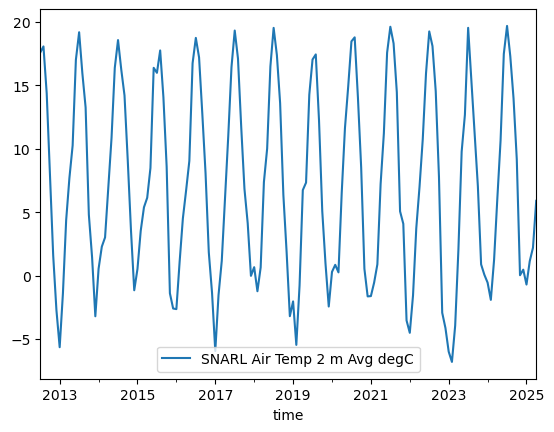

In [33]:
monthly_temperature.plot()

In the second notebook, we'll look at more sophistocated plotting we can do with Matplotlib. 

## Key things to remember (especially coming from another language)
- Zero-based indexing everywhere and always in Python. 
- Slicing of lists and arrays uses half-open intervals, meaning the *stop* value in a sequence given as *[start:stop]* is not included. So `a[0:3]` gives indices 0, 1, 2 — but not 3
- Multiplication and division default to element-wise, so use `@` for matrix multiplication
- Reshaping is row-first by default (give `order='F'` as an input variable to produce MATLAB and R type behavior)
- Indentation defines blocks of code like loops 
